# Capítulo 1 — Equações Diferenciais Ordinárias com apoio computacional em Python

*Uma introdução prática à modelagem de fenômenos que mudam com o tempo.*

Muitas perguntas interessantes em biologia, química e engenharia têm a mesma cara: **como uma quantidade muda ao longo do tempo?** Quantas células haverá amanhã? Quanto de um fármaco ainda resta no organismo daqui a seis horas? Até onde uma população consegue crescer antes de esbarrar nos próprios limites?

As **equações diferenciais ordinárias (EDOs)** são a linguagem natural para esse tipo de pergunta. Em vez de descrever diretamente o valor de uma quantidade, elas descrevem a sua **taxa de variação** — e é justamente isso que costumamos conhecer sobre um fenômeno: não *quanto* existe, mas *o quão rápido* aquilo muda.

Nesta apostila vamos construir essa ideia do zero e, lado a lado, aprender a resolver os modelos no computador com Python. A cada novo modelo seguiremos sempre o mesmo caminho:

> entender o fenômeno → escrever a equação → resolver → interpretar.

Resolver "à mão" quando der, e no computador sempre. Vale guardar desde já uma frase que vai nos acompanhar até o fim: **o computador não substitui o raciocínio matemático — ele amplia o que conseguimos enxergar.**

## O caminho da modelagem

Modelar é traduzir um fenômeno do mundo real para uma linguagem que podemos analisar e simular. Esse percurso é quase sempre o mesmo:

$$
\text{fenômeno real}\;\longrightarrow\;\text{variável de estado}\;\longrightarrow\;\text{taxa de variação}\;\longrightarrow\;\text{EDO}\;\longrightarrow\;\text{solução}\;\longrightarrow\;\text{interpretação}
$$

No nosso primeiro exemplo, ele fica assim:

$$
\text{células crescendo}\;\longrightarrow\;y(t)\;\longrightarrow\;\frac{dy}{dt}\;\longrightarrow\;\frac{dy}{dt}=ky\;\longrightarrow\;y(t)=y_0e^{kt}\;\longrightarrow\;\text{crescimento exponencial}
$$

Repare que a solução de uma EDO nunca depende só da equação. Ela depende de **três ingredientes**:

1. a **equação** diferencial em si;
2. os **parâmetros** (os números que aparecem nela);
3. a **condição inicial** (de onde a história começa).

Mude qualquer um dos três e o comportamento da solução pode mudar por completo. Guarde isso: é uma das maiores fontes de confusão no começo.

## Preparando o ambiente

Vamos usar três bibliotecas, cada uma com um papel claro:

| Biblioteca | Para quê |
|---|---|
| `numpy` | contas e vetores numéricos |
| `matplotlib` | gráficos |
| `scipy.integrate.solve_ivp` | resolver EDOs numericamente |

Execute a célula abaixo uma vez para deixar tudo pronto.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Deixa os gráficos um pouco maiores e mais legíveis (ajuste como preferir).
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.grid"] = True

print("Tudo pronto! NumPy", np.__version__)

Tudo pronto! NumPy 2.2.6


## O que é uma EDO?

Uma **equação diferencial ordinária** relaciona uma função desconhecida com as suas próprias derivadas, em relação a uma única variável independente — quase sempre, para nós, o **tempo**.

O exemplo mais simples já diz muita coisa:

$$
\frac{dy}{dt}=ky.
$$

Em palavras: *a velocidade com que $y$ cresce é proporcional ao tamanho atual de $y$*. Quanto mais existe, mais rápido aumenta. É o que acontece numa cultura de células em que cada célula se divide a um ritmo parecido — ou no seu dinheiro rendendo juros compostos.

### Lendo o sinal da derivada

A derivada $\dfrac{dy}{dt}$ é a **taxa de variação** de $y$, e só o seu sinal já conta a história antes de qualquer conta:

- $\dfrac{dy}{dt} > 0$ → $y$ está **aumentando**;
- $\dfrac{dy}{dt} < 0$ → $y$ está **diminuindo**;
- $\dfrac{dy}{dt} = 0$ → $y$ está **parado** (equilíbrio).

No modelo $\frac{dy}{dt}=ky$, com $y$ sendo o número de células, $k$ é a taxa de crescimento e $y(0)=y_0$ a quantidade inicial. Só com isso já dá para prever o formato da curva.

> ### Antes de resolver, pergunte
> Toda vez que encontrar uma EDO nova, pare e responda mentalmente:
> 1. Qual é a variável que está mudando?
> 2. A taxa de variação é positiva, negativa ou pode trocar de sinal?
> 3. Quais parâmetros controlam essa mudança?
> 4. O gráfico esperado é crescente, decrescente, em forma de "S" ou oscilante?
>
> Esse hábito vale ouro: ele permite *prever* o comportamento da solução e, depois, conferir se a conta (ou o computador) concorda com a sua intuição.

## Modelo 1 — Crescimento exponencial

$$
\frac{dy}{dt}=ky,\qquad y(0)=y_0,\qquad k>0.
$$

Esse modelo descreve situações em que a taxa de crescimento é proporcional ao que já existe: populações sem restrição de recursos, juros compostos, reações em cadeia no início.

### Resolvendo no papel

A equação é separável. Juntamos os $y$ de um lado e os $t$ do outro:

$$
\frac{1}{y}\,dy = k\,dt.
$$

Integrando os dois lados,

$$
\ln|y| = kt + C \;\Longrightarrow\; y(t)=Ae^{kt}.
$$

A condição inicial fixa a constante: em $t=0$, $y_0 = Ae^{0}=A$. Logo,

$$
\boxed{\,y(t)=y_0\,e^{kt}\,}.
$$

O sinal de $k$ decide tudo: $k>0$ cresce, $k<0$ decai, $k=0$ fica constante.

**Um número concreto.** Com $k=0{,}2$ e $y_0=10$, temos $y(t)=10\,e^{0{,}2t}$. Em $t=5$ isso dá $y(5)=10\,e^{1}\approx 27{,}2$ — quase o triplo do valor inicial.

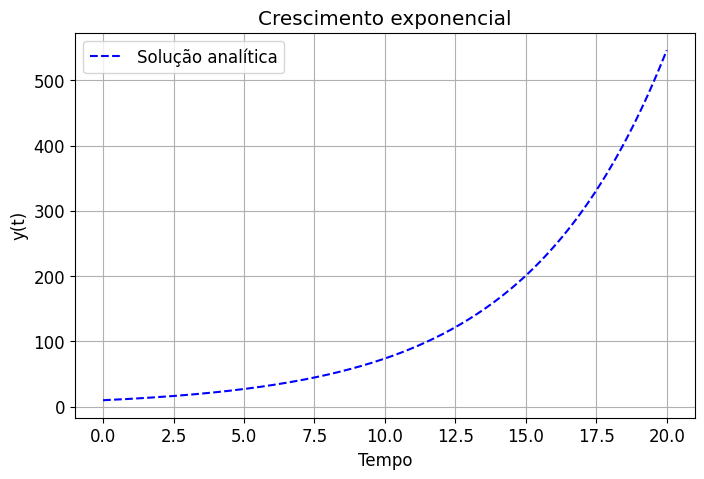

In [2]:
k = 0.2     # taxa de crescimento
y0 = 10     # valor inicial

t = np.linspace(0, 20, 200)   # 200 instantes entre t = 0 e t = 20
y = y0 * np.exp(k * t)        # solução analítica  y(t) = y0 * e^(k t)

plt.figure()
plt.plot(t, y, "--b", label="Solução analítica")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Crescimento exponencial")
plt.legend()
plt.show()

### Exercícios

**1.** Para $\frac{dy}{dt}=0{,}1\,y$ com $y(0)=20$: encontre $y(t)$ e calcule $y(10)$.

**2.** Para $\frac{dy}{dt}=0{,}35\,y$ com $y(0)=5$: encontre $y(t)$, calcule $y(4)$ e explique o papel do número $0{,}35$.

**3.** Compare $\frac{dy}{dt}=0{,}1\,y$ e $\frac{dy}{dt}=0{,}5\,y$, ambos com $y(0)=10$. Qual cresce mais rápido? Por quê?

## Modelo 1 no computador: o `solve_ivp`

Resolver à mão é ótimo para entender, mas só funciona em casos simples. A partir de agora, a maioria dos modelos será resolvida **numericamente** com a função `solve_ivp` do SciPy.

Ela resolve qualquer problema da forma

$$
\frac{dy}{dt}=f(t,y),\qquad y(t_0)=y_0,
$$

desde que você diga quem é $f$. A chamada tem este esqueleto:

```python
solve_ivp(funcao_do_modelo, (t0, tf), condicao_inicial, args=parametros, t_eval=tempos)
```

| Argumento | O que é |
|---|---|
| `funcao_do_modelo` | função Python que devolve $f(t,y)$ |
| `(t0, tf)` | intervalo de tempo da simulação |
| `condicao_inicial` | valor de $y$ em $t_0$ (sempre numa lista) |
| `args` | parâmetros extras do modelo |
| `t_eval` | instantes em que queremos guardar a solução |

### O roteiro que vamos repetir sempre

Para **todo** modelo daqui em diante seguiremos os mesmos passos:

1. escrever a função que devolve a derivada;
2. escolher os parâmetros;
3. escolher a condição inicial;
4. definir o intervalo de tempo;
5. chamar o `solve_ivp`;
6. plotar a solução;
7. interpretar a curva.

### Traduzindo a EDO para uma função

O Python precisa receber a equação como uma função. Traduzir $\frac{dy}{dt}=ky$ fica assim:

```python
def crescimento_exponencial(t, y, k):
    return [k * y[0]]
```

Dois detalhes que costumam pegar quem está começando:

- `y` chega como um **vetor**, mesmo quando há uma só variável — por isso escrevemos `y[0]`;
- a função deve **retornar uma lista** (ou array), não um número solto.

Por que `y[0]` e não `y`? Porque o `solve_ivp` trata o estado do sistema sempre como um vetor, já pensando nos casos com várias variáveis que veremos adiante. Uma EDO de uma variável é apenas o caso de um vetor com um único elemento.

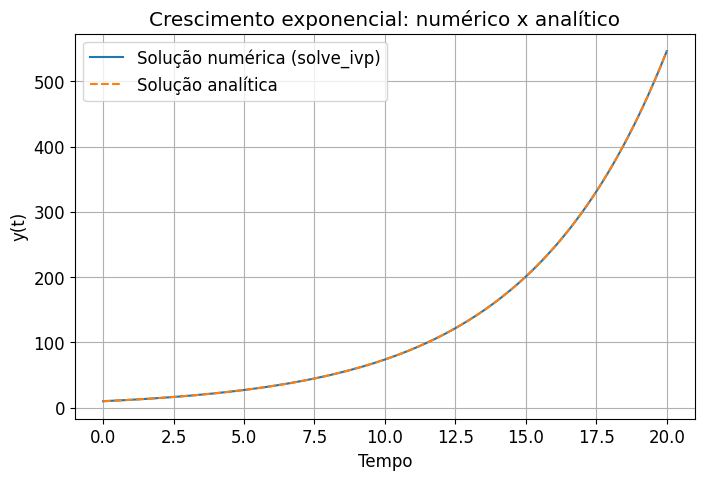

In [3]:
def crescimento_exponencial(t, y, k):
    '''dy/dt = k*y.  Aqui y[0] e a unica variavel de estado.'''
    return [k * y[0]]


k = 0.2
y0 = [10]               # condicao inicial como lista
t_span = (0, 20)
t_eval = np.linspace(0, 20, 200)

sol = solve_ivp(crescimento_exponencial, t_span, y0, args=(k,), t_eval=t_eval)
# sol.t guarda os tempos;  sol.y[0] guarda os valores de y nesses tempos.

y_exata = y0[0] * np.exp(k * t_eval)   # solucao analitica, para comparar

plt.figure()
plt.plot(sol.t, sol.y[0], label="Solução numérica (solve_ivp)")
plt.plot(t_eval, y_exata, "--", label="Solução analítica")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Crescimento exponencial: numérico x analítico")
plt.legend()
plt.show()

### Para refletir

Volte à célula anterior e troque o valor de $k$. Teste $k=0{,}05$, depois $0{,}1$, $0{,}3$ e $0{,}5$, e observe:

1. o que muda na curva quando $k$ aumenta?
2. o crescimento é linear ou não?
3. a velocidade de crescimento é a mesma o tempo todo?

A célula abaixo faz essa comparação de uma vez, colocando todas as curvas no mesmo gráfico.

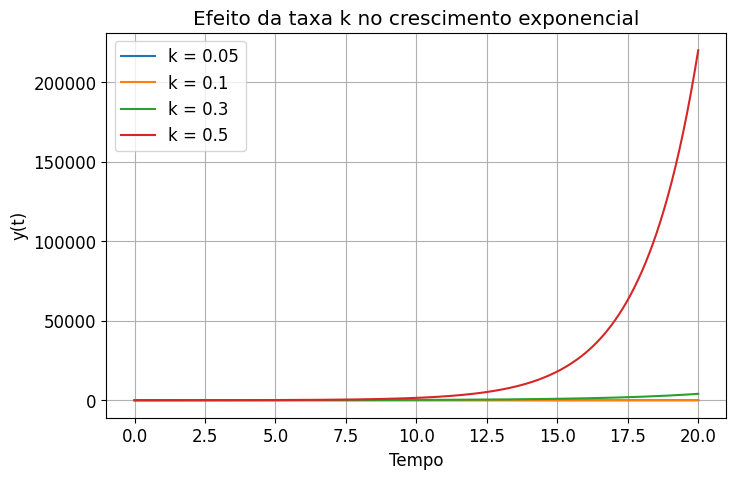

In [4]:
valores_k = [0.05, 0.1, 0.3, 0.5]
y0 = [10]
t_eval = np.linspace(0, 20, 300)

plt.figure()
for k in valores_k:
    sol = solve_ivp(crescimento_exponencial, (0, 20), y0, args=(k,), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f"k = {k}")

plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Efeito da taxa k no crescimento exponencial")
plt.legend()
plt.show()

## Modelo 2 — Decaimento exponencial

Basta trocar um sinal:

$$
\frac{dy}{dt}=-ky,\qquad y(0)=y_0,\qquad k>0,
$$

e a solução vira

$$
y(t)=y_0\,e^{-kt}.
$$

Esse pequeno sinal de menos muda toda a história: agora $y$ **diminui** com o tempo. O modelo descreve, entre outras coisas, decaimento radioativo, eliminação de um fármaco pelo organismo, degradação de um composto ou morte celular proporcional à quantidade de células.

### Duas perguntas que valem a pena

1. $y(t)$ chega *exatamente* a zero em algum momento?
2. Se $k$ for maior, o decaimento é mais rápido ou mais lento?

<details>
<summary><strong>Resposta</strong></summary>

No modelo contínuo, $y(t)=y_0e^{-kt}$ se aproxima de zero mas **nunca o atinge** em tempo finito — só chega lá no limite $t\to\infty$. E quanto maior o $k$, mais rápido cai. Repare que aqui $k$ tem o papel oposto ao do modelo anterior.

</details>

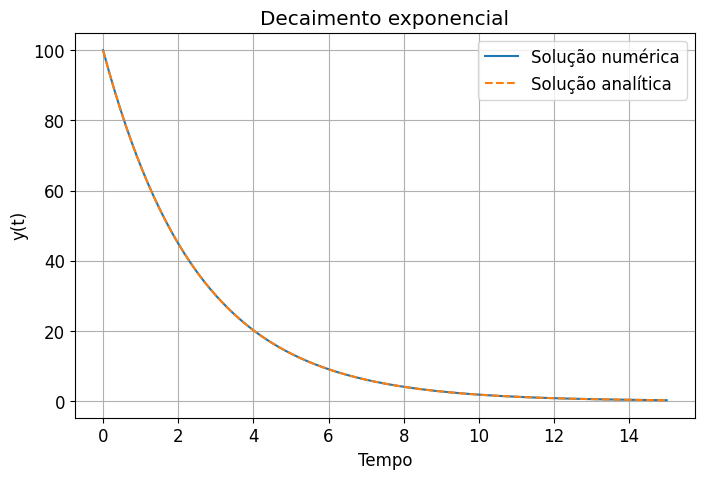

In [5]:
def decaimento_exponencial(t, y, k):
    '''dy/dt = -k*y.  O sinal negativo faz y diminuir.'''
    return [-k * y[0]]


k = 0.4
y0 = [100]
t_eval = np.linspace(0, 15, 300)

sol = solve_ivp(decaimento_exponencial, (0, 15), y0, args=(k,), t_eval=t_eval)
y_exata = y0[0] * np.exp(-k * t_eval)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Solução numérica")
plt.plot(t_eval, y_exata, "--", label="Solução analítica")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Decaimento exponencial")
plt.legend()
plt.show()

### Exercício computacional

A concentração de uma substância decai segundo

$$
\frac{dC}{dt}=-0{,}25\,C,\qquad C(0)=80.
$$

1. Resolva à mão e escreva $C(t)$.
2. Simule em Python.
3. Estime em que instante $C(t)$ fica abaixo de $10$.
4. Repita com $k=0{,}1$, $0{,}25$ e $0{,}5$ e compare.

A função `tempo_abaixo_do_limiar` abaixo ajuda no item 3: ela varre a solução numérica e devolve o primeiro instante em que $C$ cruza um limiar.

> **Como ela funciona por dentro:** `y < limiar` gera um vetor de `True`/`False`; `np.where(...)` devolve as posições onde isso é `True`; pegamos a primeira delas com `[0]` e lemos o tempo correspondente. Como a solução é avaliada em pontos discretos, o resultado é uma boa aproximação — mais fina quanto mais pontos houver em `t_eval`.

C(t) fica abaixo de 10 por volta de t = 8.36


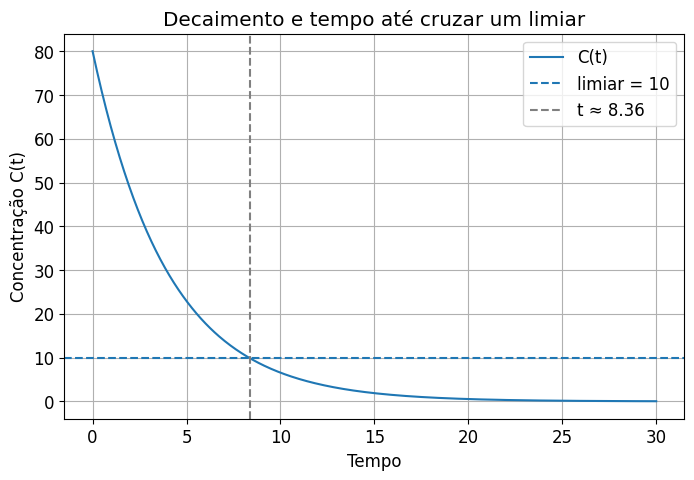

In [6]:
def tempo_abaixo_do_limiar(t, y, limiar):
    '''Primeiro instante em que y(t) fica abaixo de 'limiar'.

    Devolve None se isso nunca acontece no intervalo simulado.
    '''
    abaixo = np.where(y < limiar)[0]   # posicoes onde y < limiar
    if len(abaixo) == 0:
        return None
    return t[abaixo[0]]                # tempo da primeira delas


k = 0.25
C0 = [80]
limiar = 10
t_eval = np.linspace(0, 30, 500)

sol = solve_ivp(decaimento_exponencial, (0, 30), C0, args=(k,), t_eval=t_eval)
t_cruza = tempo_abaixo_do_limiar(sol.t, sol.y[0], limiar)

print(f"C(t) fica abaixo de {limiar} por volta de t = {t_cruza:.2f}")

plt.figure()
plt.plot(sol.t, sol.y[0], label="C(t)")
plt.axhline(limiar, linestyle="--", label=f"limiar = {limiar}")
plt.axvline(t_cruza, linestyle="--", color="gray", label=f"t ≈ {t_cruza:.2f}")
plt.xlabel("Tempo")
plt.ylabel("Concentração C(t)")
plt.title("Decaimento e tempo até cruzar um limiar")
plt.legend()
plt.show()

## Modelo 3 — Crescimento logístico

O crescimento exponencial tem um defeito: ele nunca para. Na vida real, nada cresce para sempre — falta espaço, faltam nutrientes, sobra competição. O **modelo logístico** conserta isso introduzindo um limite:

$$
\frac{dy}{dt}=r\,y\left(1-\frac{y}{K}\right).
$$

Aqui $r$ é a taxa de crescimento e $K$ é a **capacidade de suporte**: o valor máximo que o sistema comporta. A sacada está no fator $\left(1-\frac{y}{K}\right)$, que funciona como um **freio**:

- quando $y$ é pequeno ($y\ll K$), o freio vale quase $1$ e o crescimento é praticamente exponencial;
- quando $y$ se aproxima de $K$, o freio tende a $0$ e o crescimento desacelera;
- se $y$ passar de $K$, o termo fica negativo e $y$ **diminui** de volta para $K$.

O resultado é a famosa curva em forma de "S" (sigmoide). É um dos modelos mais úteis em biologia: serve para populações, biomassa, crescimento celular, volume de tumores — qualquer coisa limitada por recursos.

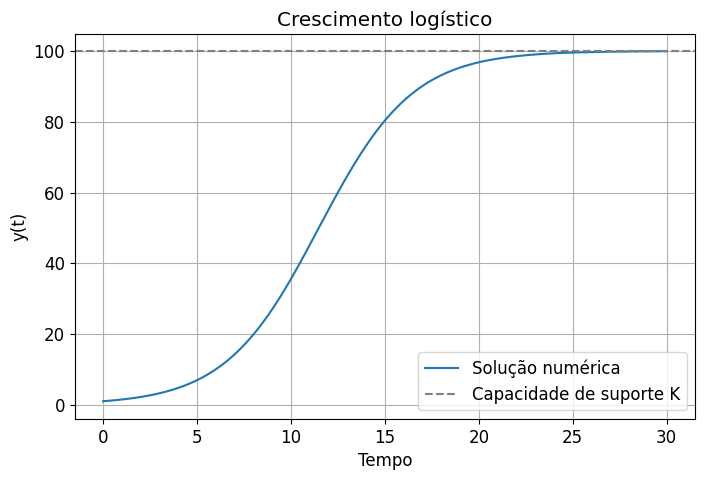

In [7]:
def crescimento_logistico(t, y, r, K):
    '''dy/dt = r*y*(1 - y/K).  r: taxa de crescimento;  K: capacidade de suporte.'''
    return [r * y[0] * (1 - y[0] / K)]


r = 0.4
K = 100
y0 = [1]
t_eval = np.linspace(0, 30, 400)

sol = solve_ivp(crescimento_logistico, (0, 30), y0, args=(r, K), t_eval=t_eval)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Solução numérica")
plt.axhline(K, linestyle="--", color="gray", label="Capacidade de suporte K")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Crescimento logístico")
plt.legend()
plt.show()

### Pontos de equilíbrio

Equilíbrio é onde nada muda, ou seja, onde $\frac{dy}{dt}=0$. No modelo logístico:

$$
r\,y\left(1-\frac{y}{K}\right)=0 \;\Longrightarrow\; y^*=0 \quad\text{ou}\quad y^*=K.
$$

São dois equilíbrios de naturezas opostas (com $r>0$):

- $y^*=0$ é **instável**: qualquer populaçãozinha inicial cresce e foge dele;
- $y^*=K$ é **estável**: soluções que começam abaixo ou acima de $K$ acabam convergindo para ele.

"Estável" e "instável" é só isso: a solução *foge* de um equilíbrio instável e é *atraída* por um estável. Vamos ver isso na prática variando a condição inicial.

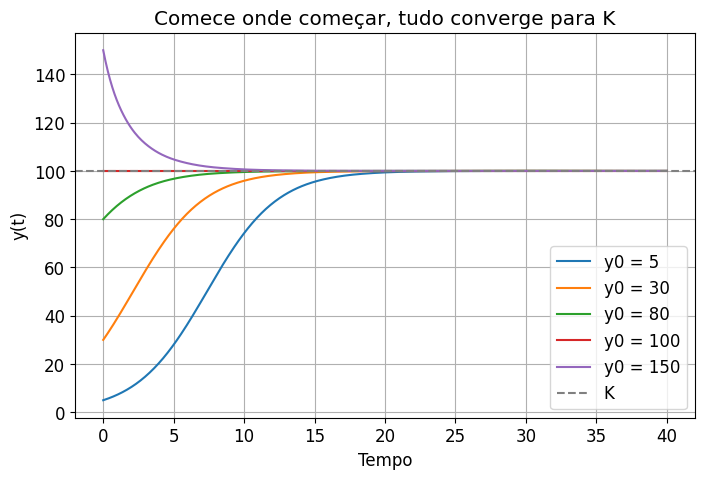

In [8]:
r = 0.4
K = 100
condicoes_iniciais = [5, 30, 80, 100, 150]
t_eval = np.linspace(0, 40, 500)

plt.figure()
for y0 in condicoes_iniciais:
    sol = solve_ivp(crescimento_logistico, (0, 40), [y0], args=(r, K), t_eval=t_eval)
    plt.plot(sol.t, sol.y[0], label=f"y0 = {y0}")

plt.axhline(K, linestyle="--", color="gray", label="K")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Comece onde começar, tudo converge para K")
plt.legend()
plt.show()

### Atividade guiada: do qualitativo ao computacional

Vamos juntar tudo num único modelo logístico:

$$
\frac{dN}{dt}=0{,}5\,N\left(1-\frac{N}{200}\right),\qquad N(0)=20.
$$

Pense em $N$ como uma população, uma biomassa ou uma cultura de células num ambiente com recursos limitados.

**Parte A — Identificação.** Quem é a variável dependente? E a independente? Qual a condição inicial? Quais os parâmetros e o significado de cada um? O modelo é linear ou não linear?

**Parte B — Análise qualitativa (antes de simular).** Encontre os equilíbrios resolvendo $f(N)=0$. Analise o sinal de $f(N)$ para $0<N<200$ e para $N>200$, e classifique cada equilíbrio. Como $N(0)=20$, você espera que $N$ cresça ou diminua? Para onde tende quando $t\to\infty$? E se começasse em $N(0)=250$?

**Parte C — Solução analítica.** A solução geral do logístico é

$$
N(t)=\frac{K}{1+\left(\frac{K-N_0}{N_0}\right)e^{-rt}}.
$$

Substitua $r=0{,}5$, $K=200$, $N_0=20$. Confira que $N(0)=20$ e, usando que $e^{-0{,}5t}\to 0$, justifique o limite de $N(t)$ quando $t\to\infty$.

**Parte D — Crescimento máximo.** No logístico, a curva é mais inclinada exatamente em $N=K/2$. Quanto é isso aqui? Está abaixo ou acima de $K$? A curva sobe mais rápido no início, no meio ou perto do fim?

**Parte E — Simulação.** Use a célula abaixo para conferir todas as suas previsões.

Equilíbrios:           N* = 0  e  N* = 200
Crescimento máximo em:  N = K/2 = 100.0
N atinge 90% de K em:   t ≈ 8.84


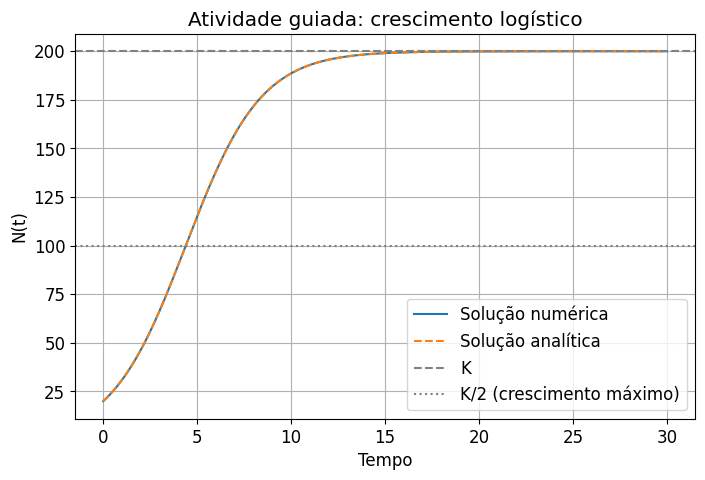

In [9]:
r = 0.5
K = 200
N0 = 20
t_eval = np.linspace(0, 30, 500)

sol = solve_ivp(crescimento_logistico, (0, 30), [N0], args=(r, K), t_eval=t_eval)
N_exata = K / (1 + ((K - N0) / N0) * np.exp(-r * t_eval))   # solucao analitica

# Instante em que N atinge 90% de K
acima_90 = np.where(sol.y[0] >= 0.9 * K)[0]
t_90 = sol.t[acima_90[0]] if len(acima_90) else None

print(f"Equilíbrios:           N* = 0  e  N* = {K}")
print(f"Crescimento máximo em:  N = K/2 = {K/2}")
if t_90 is not None:
    print(f"N atinge 90% de K em:   t ≈ {t_90:.2f}")

plt.figure()
plt.plot(sol.t, sol.y[0], label="Solução numérica")
plt.plot(t_eval, N_exata, "--", label="Solução analítica")
plt.axhline(K, linestyle="--", color="gray", label="K")
plt.axhline(K / 2, linestyle=":", color="gray", label="K/2 (crescimento máximo)")
plt.xlabel("Tempo")
plt.ylabel("N(t)")
plt.title("Atividade guiada: crescimento logístico")
plt.legend()
plt.show()

## Organizando o código: uma função reutilizável

Já reparou que toda simulação até aqui repete a mesma receita? Montar `t_eval`, chamar o `solve_ivp`, devolver a solução. Quando isso acontece, vale empacotar a receita numa função e parar de copiar e colar. Além de deixar o código mais limpo, fica bem mais fácil testar vários cenários.

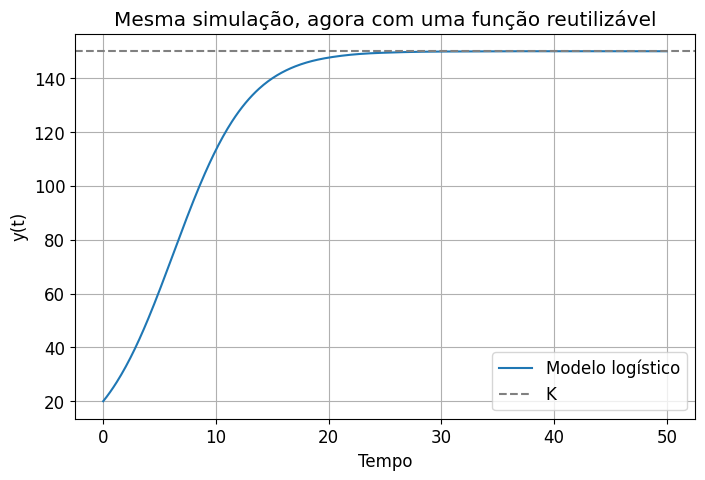

In [10]:
def simular_1d(modelo, parametros, y0, t0, tf, n_pontos=500):
    '''Resolve uma EDO de uma variavel e devolve o objeto do solve_ivp.'''
    t_eval = np.linspace(t0, tf, n_pontos)
    return solve_ivp(modelo, (t0, tf), [y0], args=parametros, t_eval=t_eval)


# Exemplo de uso com o modelo logistico
sol = simular_1d(crescimento_logistico, parametros=(0.3, 150), y0=20, t0=0, tf=50)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Modelo logístico")
plt.axhline(150, linestyle="--", color="gray", label="K")
plt.xlabel("Tempo")
plt.ylabel("y(t)")
plt.title("Mesma simulação, agora com uma função reutilizável")
plt.legend()
plt.show()

## Outra forma de enxergar: o sinal da derivada

Até agora olhamos $y$ contra o tempo. Existe um segundo ponto de vista, muito útil: olhar a **derivada em função de $y$**. Para uma EDO autônoma $\frac{dy}{dt}=f(y)$, basta desenhar $f(y)$ e ler onde ela é positiva, negativa ou nula:

- onde $f(y)>0$, a solução **sobe**;
- onde $f(y)<0$, a solução **desce**;
- onde $f(y)=0$, há um **equilíbrio**.

Isso permite prever o comportamento sem nem resolver a equação. Vamos fazer esse gráfico para o logístico.

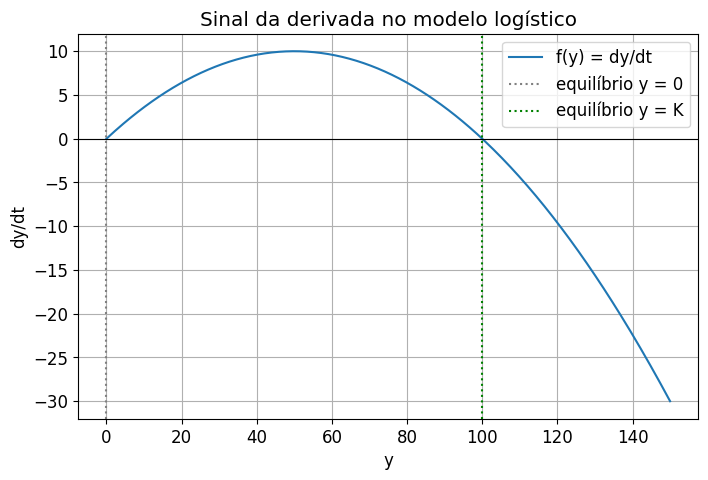

In [11]:
r = 0.4
K = 100
y = np.linspace(0, 150, 400)
f = r * y * (1 - y / K)

plt.figure()
plt.plot(y, f, label="f(y) = dy/dt")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, linestyle=":", color="gray", label="equilíbrio y = 0")
plt.axvline(K, linestyle=":", color="green", label="equilíbrio y = K")
plt.xlabel("y")
plt.ylabel("dy/dt")
plt.title("Sinal da derivada no modelo logístico")
plt.legend()
plt.show()

Repare na curva: entre $0$ e $K$ ela está **acima** do eixo ($f>0$), então a solução cresce nessa faixa; acima de $K$ ela fica **abaixo** ($f<0$), e a solução decresce. Em ambos os lados, o movimento aponta para $K$ — é exatamente isso que torna $K$ um equilíbrio estável. Reencontramos, num único gráfico estático, a mesma conclusão que antes só apareceu depois de simular.

## Sistemas de EDOs: quando há mais de uma variável

Muitos fenômenos não dependem de uma quantidade só, mas da **interação** entre várias: biomassa que consome substrato, enzima que converte substrato em produto, tumor que interage com o sistema imune, presas e predadores. Nesses casos temos um **sistema** de EDOs acopladas:

$$
\frac{dx}{dt}=f(t,x,y),\qquad \frac{dy}{dt}=g(t,x,y).
$$

A diferença essencial é que as variáveis evoluem **ao mesmo tempo** e influenciam umas às outras.

### O exemplo clássico: presa-predador (Lotka-Volterra)

$$
\frac{dx}{dt}=a\,x-b\,xy,\qquad \frac{dy}{dt}=-c\,y+d\,xy.
$$

Aqui $x$ são as presas e $y$ os predadores. Sem predadores, as presas cresceriam livremente ($ax$); o termo $-bxy$ representa os encontros em que presas são caçadas. Os predadores, por sua vez, morreriam sozinhos ($-cy$), mas se alimentam desses encontros ($+dxy$). Dessa disputa nascem as oscilações que veremos a seguir.

No Python, a única novidade é que a função agora recebe e devolve **duas** componentes.

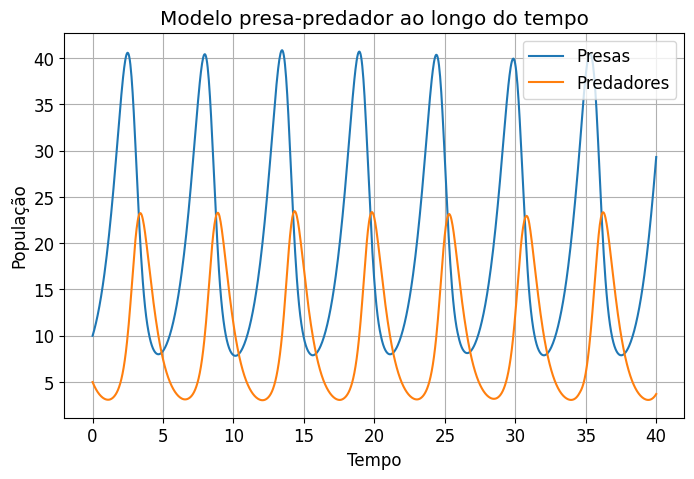

In [12]:
def lotka_volterra(t, z, a, b, c, d):
    '''Presa-predador.  z[0] = presas (x);  z[1] = predadores (y).'''
    x, y = z
    dxdt = a * x - b * x * y
    dydt = -c * y + d * x * y
    return [dxdt, dydt]


a, b, c, d = 1.0, 0.1, 1.5, 0.075
z0 = [10, 5]                       # 10 presas, 5 predadores
t_eval = np.linspace(0, 40, 1000)

sol = solve_ivp(lotka_volterra, (0, 40), z0, args=(a, b, c, d), t_eval=t_eval)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Presas")
plt.plot(sol.t, sol.y[1], label="Predadores")
plt.xlabel("Tempo")
plt.ylabel("População")
plt.title("Modelo presa-predador ao longo do tempo")
plt.legend()
plt.show()

O **plano de fase** mostra as duas populações uma contra a outra, deixando o tempo implícito. A trajetória fechada revela o ciclo: presas e predadores se perseguem eternamente, girando em torno de um ponto central.

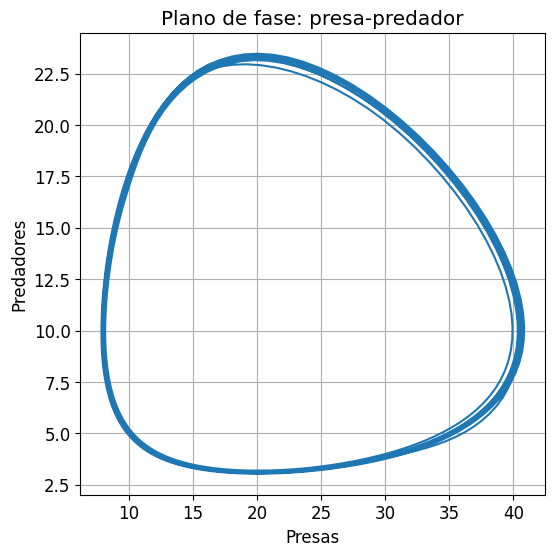

In [13]:
plt.figure(figsize=(6, 6))
plt.plot(sol.y[0], sol.y[1])
plt.xlabel("Presas")
plt.ylabel("Predadores")
plt.title("Plano de fase: presa-predador")
plt.show()

### Exercícios

1. Mude as condições iniciais (mais presas, menos predadores) e veja o efeito.
2. Aumente $b$ (a taxa de predação). O que acontece com a amplitude das oscilações?
3. Olhe os dois gráficos — o temporal e o plano de fase — e explique, com suas palavras, **por que** as populações oscilam em vez de se estabilizarem.

## Aplicação 1 — Crescimento microbiano em biorreator batelada

Em bioprocessos, EDOs modelam o crescimento de microrganismos, o consumo de substrato e a formação de produtos. Um caso clássico é o **biorreator em batelada**: um tanque fechado, sem entrada nem saída de material durante o processo, em que os microrganismos crescem consumindo o substrato disponível.

Vamos acompanhar duas variáveis: a biomassa $X(t)$ e o substrato $S(t)$.

### A cinética de Monod

A velocidade de crescimento dos microrganismos não é constante: ela depende de quanto substrato há disponível. A **cinética de Monod** captura isso:

$$
\mu(S)=\mu_{\max}\,\frac{S}{K_s+S}.
$$

Quando há fartura de substrato ($S$ grande), $\mu$ se aproxima do máximo $\mu_{\max}$. Quando o substrato escasseia ($S$ pequeno), o crescimento despenca. A constante $K_s$ marca a "meia saturação": o valor de $S$ em que a velocidade é metade da máxima.

O modelo da batelada junta crescimento e consumo:

$$
\frac{dX}{dt}=\mu(S)\,X,\qquad \frac{dS}{dt}=-\frac{1}{Y_{X/S}}\,\mu(S)\,X,
$$

onde $Y_{X/S}$ é o **rendimento**: quanta biomassa se forma por unidade de substrato consumido.

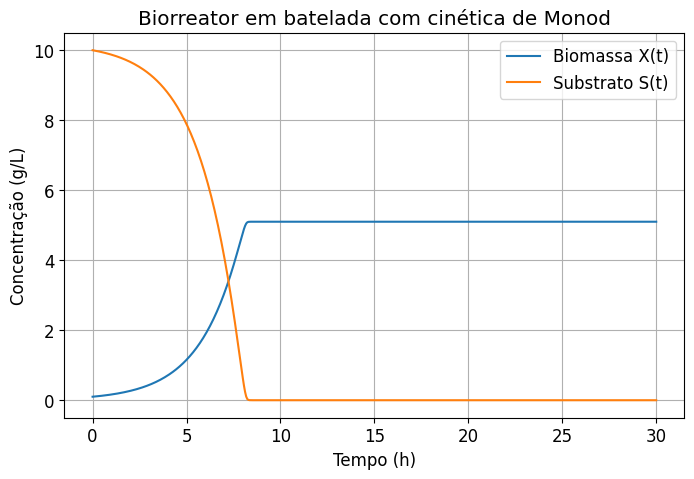

In [14]:
def biorreator_batelada(t, y, mu_max, Ks, Yxs):
    '''Batelada com cinetica de Monod.  y[0] = biomassa X;  y[1] = substrato S.'''
    X, S = y
    S = max(S, 0)                  # evita S negativo por erro numerico
    mu = mu_max * S / (Ks + S)     # taxa de crescimento de Monod
    dXdt = mu * X
    dSdt = -(1 / Yxs) * mu * X
    return [dXdt, dSdt]


mu_max, Ks, Yxs = 0.5, 0.2, 0.5   # 1/h, g/L, gX/gS
y0 = [0.1, 10.0]                  # X0 = 0.1 g/L,  S0 = 10 g/L
t_eval = np.linspace(0, 30, 500)

sol = solve_ivp(biorreator_batelada, (0, 30), y0, args=(mu_max, Ks, Yxs), t_eval=t_eval)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Biomassa X(t)")
plt.plot(sol.t, sol.y[1], label="Substrato S(t)")
plt.xlabel("Tempo (h)")
plt.ylabel("Concentração (g/L)")
plt.title("Biorreator em batelada com cinética de Monod")
plt.legend()
plt.show()

### Interpretação

A curva conta uma história em três atos. No começo há substrato de sobra, então a biomassa cresce quase exponencialmente. Conforme o substrato é consumido, $\mu(S)$ cai e o crescimento perde força. Quando o substrato se esgota, a biomassa estaciona — é o fim natural de uma batelada.

### Atividades

1. Aumente $S_0$. O que acontece com a biomassa final?
2. Aumente $X_0$. O processo termina mais rápido ou mais devagar?
3. Altere $\mu_{\max}$ e depois $K_s$. Qual o efeito de cada um?
4. Explique, com suas palavras, o papel do rendimento $Y_{X/S}$.

## Aplicação 2 — Reação enzimática

Outra situação comum em biotecnologia é uma enzima convertendo um substrato $S$ em produto $P$. A velocidade dessa conversão costuma seguir a cinética de **Michaelis-Menten** — irmã próxima da de Monod:

$$
v(S)=V_{\max}\,\frac{S}{K_m+S}.
$$

$V_{\max}$ é a velocidade máxima e $K_m$ é a constante de Michaelis (o $S$ em que a velocidade é metade da máxima). O modelo de conversão fica:

$$
\frac{dS}{dt}=-v(S),\qquad \frac{dP}{dt}=Y_{P/S}\,v(S),
$$

com $Y_{P/S}$ sendo o rendimento de produto por substrato consumido. Tudo o que o substrato perde, o produto ganha (a menos do rendimento).

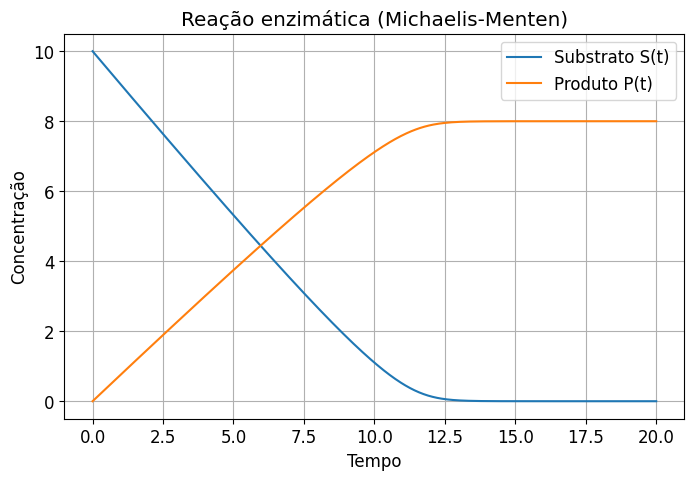

In [15]:
def reacao_enzimatica(t, y, Vmax, Km, Yps):
    '''Michaelis-Menten.  y[0] = substrato S;  y[1] = produto P.'''
    S, P = y
    S = max(S, 0)
    v = Vmax * S / (Km + S)
    return [-v, Yps * v]


Vmax, Km, Yps = 1.0, 0.5, 0.8
y0 = [10.0, 0.0]                  # S0 = 10,  P0 = 0
t_eval = np.linspace(0, 20, 500)

sol = solve_ivp(reacao_enzimatica, (0, 20), y0, args=(Vmax, Km, Yps), t_eval=t_eval)

plt.figure()
plt.plot(sol.t, sol.y[0], label="Substrato S(t)")
plt.plot(sol.t, sol.y[1], label="Produto P(t)")
plt.xlabel("Tempo")
plt.ylabel("Concentração")
plt.title("Reação enzimática (Michaelis-Menten)")
plt.legend()
plt.show()

### Atividades

1. Aumente $V_{\max}$: a reação fica mais rápida?
2. Aumente $K_m$: o que muda na velocidade?
3. Altere $Y_{P/S}$: o que muda na produção final?
4. Estime o tempo para consumir 90% do substrato — a função abaixo faz isso.

In [16]:
def tempo_para_consumir(t, S, S0, fracao=0.9):
    '''Tempo aproximado para consumir uma 'fracao' do substrato inicial S0.'''
    restante = S0 * (1 - fracao)        # quanto sobra quando 'fracao' foi consumida
    chegou = np.where(S <= restante)[0]
    return t[chegou[0]] if len(chegou) else None


t_90 = tempo_para_consumir(sol.t, sol.y[0], S0=10.0, fracao=0.9)
if t_90 is not None:
    print(f"90% do substrato é consumido por volta de t = {t_90:.2f}")
else:
    print("O substrato não chegou a 90% de consumo no intervalo simulado.")

90% do substrato é consumido por volta de t = 10.18


## Mini-projetos finais

Hora de juntar tudo. Cada projeto pede modelagem, simulação e — principalmente — interpretação.

### Mini-projeto 1 — Crescimento tumoral com tratamento

Modelos podem representar o crescimento de um tumor e o efeito de um tratamento. Uma versão simples combina crescimento logístico com uma morte induzida pelo tratamento:

$$
\frac{dT}{dt}=r\,T\left(1-\frac{T}{K}\right)-\alpha\,T,
$$

onde $T(t)$ é o volume tumoral, $r$ a taxa de crescimento, $K$ a capacidade de suporte, $\alpha$ a intensidade do tratamento e $T(0)=T_0$ o volume inicial.

**Tarefas.** Explique biologicamente cada termo. Encontre os equilíbrios. Simule sem tratamento ($\alpha=0$) e depois com tratamento fraco, moderado e forte, comparando tudo num só gráfico. Descubra para quais valores de $\alpha$ o tumor tende a regredir e escreva uma conclusão.

**Para pensar.** O que acontece quando $\alpha=0$? E quando $0<\alpha<r$? E quando $\alpha=r$ ou $\alpha>r$? O modelo é realista para qualquer $T$? Que limitações ele tem e como poderia ser melhorado?

### Mini-projeto 2 — Biomassa e substrato em batelada

Reaproveite o modelo de Monod desta apostila:

$$
\mu(S)=\mu_{\max}\frac{S}{K_s+S},\qquad \frac{dX}{dt}=\mu(S)X,\qquad \frac{dS}{dt}=-\frac{1}{Y_{X/S}}\mu(S)X.
$$

**Tarefas.** Explique o significado de cada variável e parâmetro. Simule para diferentes valores de $S_0$ e de $\mu_{\max}$, e veja como $K_s$ afeta a velocidade. Calcule a biomassa final e o tempo para consumir 95% do substrato. Discuta qual cenário é mais eficiente em produção de biomassa.

**Para pensar.** Qual $S_0$ gerou mais biomassa? Aumentar $S_0$ é sempre vantajoso? O que significa um $K_s$ baixo? Como esse tipo de modelo ajuda no planejamento de uma fermentação, e quais são as suas limitações?

## Glossário rápido

| Termo | Significado |
|---|---|
| EDO | Equação diferencial ordinária |
| Variável de estado | Quantidade que muda com o tempo |
| Parâmetro | Valor fixo que controla o comportamento do modelo |
| Condição inicial | Valor da variável no tempo inicial |
| Solução analítica | Fórmula explícita para a solução |
| Solução numérica | Aproximação computacional da solução |
| Equilíbrio | Valor em que a derivada é zero |
| Estabilidade | Tendência de uma solução de se aproximar ou se afastar de um equilíbrio |
| Sistema de EDOs | Conjunto de equações diferenciais acopladas |
| Plano de fase | Gráfico de uma variável contra outra |
| Cinética de Monod | Modelo saturável para crescimento microbiano |
| Michaelis-Menten | Modelo saturável para reação enzimática |

## Para fechar

Ao longo da apostila, todo modelo passou pelos mesmos passos: identificar a variável de estado e os parâmetros, ler o sinal da derivada, procurar equilíbrios, simular e — sempre — interpretar o resultado no contexto do problema. Esse roteiro é o que você leva para qualquer EDO nova, conhecida ou não.

E todo modelo, por mais diferente que parecesse, virou código com o mesmo esqueleto:

```python
def modelo(t, y, parametros):
    # 1. separar as variáveis de estado a partir de y
    # 2. calcular as derivadas
    # 3. devolvê-las numa lista
    return [derivadas]

sol = solve_ivp(modelo, (t0, tf), condicoes_iniciais, args=(parametros,), t_eval=tempos)
```

Fica a ideia central de tudo: a simulação não substitui a matemática. Ela serve para **explorar cenários, testar hipóteses e enxergar comportamentos** que seriam difíceis de prever só no papel. O melhor trabalho acontece quando os dois andam juntos — você prevê com a análise e confirma (ou se surpreende) com o computador.

## Referências e para saber mais

**Equações diferenciais e modelagem matemática**
- BOYCE, W. E.; DIPRIMA, R. C.; MEADE, D. B. *Elementary Differential Equations and Boundary Value Problems*. 11. ed. Hoboken: Wiley, 2017.
- ZILL, D. G. *Equações Diferenciais com Aplicações em Modelagem*. 3. ed. São Paulo: Cengage Learning, 2016.
- STROGATZ, S. H. *Nonlinear Dynamics and Chaos*. 2. ed. Boca Raton: CRC Press, 2015.
- BASSANEZI, R. C. *Ensino-aprendizagem com Modelagem Matemática*. 3. ed. São Paulo: Contexto, 2002.

**Modelos em biologia**
- EDELSTEIN-KESHET, L. *Mathematical Models in Biology*. Philadelphia: SIAM, 2005.
- MURRAY, J. D. *Mathematical Biology I: An Introduction*. 3. ed. New York: Springer, 2002.
- BRITTON, N. F. *Essential Mathematical Biology*. London: Springer, 2003.

**Bioprocessos e cinética enzimática**
- DORAN, P. M. *Bioprocess Engineering Principles*. 2. ed. Waltham: Academic Press, 2013.
- SHULER, M. L.; KARGI, F. *Bioprocess Engineering: Basic Concepts*. 2. ed. Upper Saddle River: Prentice Hall, 2002.
- NELSON, D. L.; COX, M. M. *Lehninger Principles of Biochemistry*. 7. ed. New York: W. H. Freeman, 2017. (cinética de Michaelis-Menten)
- MONOD, J. The growth of bacterial cultures. *Annual Review of Microbiology*, v. 3, p. 371-394, 1949.

**Ferramentas computacionais**
- HARRIS, C. R. et al. Array programming with NumPy. *Nature*, v. 585, p. 357-362, 2020.
- VIRTANEN, P. et al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, v. 17, p. 261-272, 2020.
- HUNTER, J. D. Matplotlib: a 2D graphics environment. *Computing in Science & Engineering*, v. 9, n. 3, p. 90-95, 2007.
- Documentação do `scipy.integrate.solve_ivp`: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html>